# Google Colab Tutorial and Sierra Mercury DataSet

## Research Question

How does mercury associated with historical mining move through aquatic ecosystems?

Specifically:
- How does mercury differ between water, sediment, and organisms?
- Do higher organisms (like fish) show evidence of bioaccumulation?

## Key Terms

- **Total Mercury (THg):** All mercury measured in a sample
- **Methylmercury (MeHg):** Toxic form that accumulates in organisms
- **Bioaccumulation:** Increase of a substance within an organism over time
- **Biomagnification:** Increase in concentration across trophic levels

Google Colab tutorial: Sierra Nevada mercury dataset
1) Create a new Colab notebook

Go to Google Colab and create a blank notebook.

Initial datasets of interest: https://www.sciencebase.gov/catalog/item/5f91e00782ce720ee2d33c5b

T2_Study_Sites.csv

T3_Water_Mercury.csv  

T4_Sediment_Mercury.csv

T5_Invertebrates_Mercury.csv

T7_Fish_Mercury.csv

T15_GeometricMean_MercuryConcentrations.csv


## In the first code cell, paste this:

In [47]:
# ============================================================
# USGS Mercury Dataset Starter Notebook
# Historical mining, Sierra Nevada / Trinity Mountains, CA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os
import re

def inspect_column(df, col):
    print(f"\nColumn: {col}")
    print(df[col].head(10))
    print("\nData type:", df[col].dtype)
    print("\nUnique examples:")
    print(df[col].dropna().astype(str).head(20).tolist())

def find_mercury_columns(df, name):
    cols = [c for c in df.columns if any(k in c.lower() for k in ["hg", "mercury", "mehg", "methyl"])]
    print(f"\n{name} mercury-related columns:")
    for c in cols:
        print(" -", c)

def clean_numeric_value(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x in ["", "NA", "ND", "nan", "None"]:
        return np.nan

    # Remove censoring symbols like < or >
    x = re.sub(r"[<>]", "", x)
    x = x.replace(",", "")

    try:
        return float(x)
    except:
        return np.nan

def add_clean_columns(df, column_dict, suffix="_clean"):
    for short_name, original_col in column_dict.items():
        df[short_name + suffix] = df[original_col].apply(clean_numeric_value)

# Make plots a little larger and easier to read
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [48]:
# Download all attached files from the USGS ScienceBase item as one zip

zip_url = "https://www.sciencebase.gov/catalog/file/get/5f91e00782ce720ee2d33c5b"
zip_name = "Geochemicaldata.zip"
extract_dir = "usgs_mercury_data"

# Download
r = requests.get(zip_url, timeout=120)
r.raise_for_status()

with open(zip_name, "wb") as f:
    f.write(r.content)

print(f"Downloaded: {zip_name} ({len(r.content):,} bytes)")

# Unzip
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(extract_dir)
    print("Extracted files:")
    for name in z.namelist():
        print(" -", name)

print(f"\nFiles extracted into: {extract_dir}")

Downloaded: Geochemicaldata.zip (3,805,038 bytes)
Extracted files:
 - T1_Data_Dictionary.csv
 - T2_Study_Sites.csv
 - T3_Water_Mercury.csv
 - T4_Sediment_Mercury.csv
 - T5_Invertebrates_Mercury.csv
 - T6_Frogs_Mercury.csv
 - T7_Fish_Mercury.csv
 - T8_Water_FieldParameters.csv
 - T9_Water_Isotopes_Nutrients_MajorIons.csv
 - T10_Water_TraceElements_Filtered.csv
 - T11_Water_TraceElements_Unfiltered.csv
 - T12_Sediment_TraceElements.csv
 - T13_Invertebrates_TraceElements.csv
 - T14_Fish_TraceElements.csv
 - T15_GeometricMean_MercuryConcentrations.csv
 - T16_Normalized_Mercury_Values.csv
 - Geochem_Data_Historic_Mining.xml
 - Relief Hill_2014.jpg

Files extracted into: usgs_mercury_data


In [50]:
base = "usgs_mercury_data"

sites = pd.read_csv(os.path.join(base, "T2_Study_Sites.csv"))
water = pd.read_csv(os.path.join(base, "T3_Water_Mercury.csv"))
sediment = pd.read_csv(os.path.join(base, "T4_Sediment_Mercury.csv"))
invert = pd.read_csv(os.path.join(base, "T5_Invertebrates_Mercury.csv"))
fish = pd.read_csv(os.path.join(base, "T7_Fish_Mercury.csv"))
geo_mean = pd.read_csv(os.path.join(base, "T15_GeometricMean_MercuryConcentrations.csv"))

print("Loaded core tables.")
print("sites:", sites.shape)
print("water:", water.shape)
print("sediment:", sediment.shape)
print("invert:", invert.shape)
print("fish:", fish.shape)
print("geo_mean:", geo_mean.shape)

Loaded core tables.
sites: (250, 5)
water: (263, 15)
sediment: (203, 12)
invert: (613, 16)
fish: (83, 17)
geo_mean: (250, 16)


In [51]:
# Quick peek at the first few rows
display(sites.head())
display(water.head())
display(sediment.head())
display(invert.head())
display(fish.head())
display(geo_mean.head())

,Station Map ID,USGS Station Name,USGS Station Number,Latitude,Longitude
0,AR-01,CANYON C BL GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,390945120502401,39.16156,-120.84049
1,AR-02,CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,390945120502402,39.16351,-120.84022
2,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,390945120562001,39.16240,-120.84161
3,AR-05,GOLD RUN MINE POND NR INDIANA RAVINE NR GOLD RUN,390932120504601,39.15879,-120.84716
4,AR-06,KEYSTONE MINE TUNNEL OUTLET NR FORRESTHILLS CA,390305120500301,39.05139,-120.83417


,Station Map ID,USGS Station Name,USGS Station Number,Date,Time,Sample Type,Data References,"Mercury, Unfiltered (ng/L)","Mercury, Unfiltered Data Source","Mercury, Filtered (ng/L)","Mercury, Filtered Data Source","Methylmercury, Unfiltered (ng/L)","Methylmercury, Unfiltered Data Source","Methylmercury, Filtered (ng/L)","Methylmercury, Filtered Data Source"
0,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,390945120562001,2/21/2001,10:30,Environmental,NP,22.3,C2,1.1,C2,<0.04,W1,<0.04,W1
1,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,390945120562001,11/6/2002,13:00,Environmental,NP,58.5,C2,11.0,C2,<0.04,W1,<0.04,W1
2,AR-05,GOLD RUN MINE POND NR INDIANA RAVINE NR GOLD RUN,390932120504601,2/21/2001,12:30,Environmental,NP,1.8,C2,0.9,C2,<0.04,W1,<0.04,W1
3,AR-06,KEYSTONE MINE TUNNEL OUTLET NR FORRESTHILLS CA,390305120500301,11/6/2002,17:00,Environmental,NP,2.9,C2,E<0.3,C2,<0.04,W1,<0.04,W1
4,AR-07,GLEESON DIGGINS MAIN SLUICE CUT NR IOWA HILL CA,390455120510601,2/7/2002,15:00,Environmental,NP,22.2,C2,1.4,C2,0.16,W1,E0.04,W1


,Station Map ID,USGS Station Name,USGS Station Number,Date,Time,Sample Type,Data References,"Total Mercury, Dry (ng/g)",Total Mercury Data Source,"Methylmercury, Dry (ng/g)",Methylmercury Data Source,Loss On Ignition (percent)
0,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,3.909451e+14,11/06/2002,13:30,Environmental,NP,"2,450",W1,<0.08,W1,1.58
1,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,3.909451e+14,11/06/2002,13:30,Environmental,NP,"15,240",C1,ND,ND,ND
2,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,3.909451e+14,11/06/2002,13:31,Field Replicate,NP,"15,200",C1,ND,ND,ND
3,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,3.909451e+14,11/06/2002,13:32,Field Replicate,NP,"17,000",C1,ND,ND,ND
4,AR-06,KEYSTONE MINE TUNNEL OUTLET NR FORRESTHILLS CA,3.903051e+14,11/06/2002,17:05,Environmental,NP,187,W1,<0.08,W1,4.03


,Station Map ID,USGS Station Name,USGS Station Number,Date,Sample Type,Data References,Common name,Order,Family,Sample Size,Total Sample Weight (g),Moisture (percent),"Total mercury, Wet (micrograms/g)","Methylmercury, Wet (micrograms/g)",MeHg/THg (percent),Age
0,AR-01,CANYON C BL GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,6/27/2002,Environmental,NP,Spiketail Dragonflies,Odonata,Cordulegastridae,2,1.14,75.6,0.057,0.0788,137.4,Immature
1,AR-01,CANYON C BL GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,6/27/2002,Environmental,NP,Predaceous stonefly,Plecoptera,Perlidae,5,0.73,77.1,0.057,0.0543,94.8,Immature
2,AR-01,CANYON C BL GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,6/27/2002,Environmental,NP,Water striders,Hemiptera,Gerridae,25,1.87,62.6,0.109,0.0875,80.4,Adult
3,AR-02,CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,6/27/2002,Environmental,NP,Dobsonflies,Megaloptera,Corydalidae,3,1.94,73.5,0.07,0.0440,63.1,Immature
4,AR-02,CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,6/27/2002,Environmental,NP,Darner Dragonflies,Odonata,Aeshnidae,1,0.56,83.5,0.04,0.0408,101.6,Immature


,Station Map ID,USGS Station Name,USGS Station Number,Date,Sample Type,Common name,Genus and Species,Sample Size,Body Part,Total Length (mm),Total Length Standard Deviation,Total Weight (g),Total weight Standard Deviation,"Total Mercury, Dry (mg/kg)","Total Mercury, Wet (mg/kg)",Moisture (percent),Gender
0,BR-01,BEAR R A HWY 20 NR EMIGRANT GAP CA,391823120404101,8/26/1999,Environmental,Brown trout,Salmo trutta,1,Fillet,295.0,ND,274.79,ND,0.429,0.095,77.8,Female
1,BR-01,BEAR R A HWY 20 NR EMIGRANT GAP CA,391823120404101,8/26/1999,Environmental,Brown trout,Salmo trutta,1,Fillet,265.0,ND,180.36,ND,0.344,0.082,76.3,Male
2,BR-01,BEAR R A HWY 20 NR EMIGRANT GAP CA,391823120404101,8/26/1999,Environmental,Brown trout,Salmo trutta,1,Fillet,230.0,ND,118.13,ND,0.316,0.063,80.2,Female
3,BR-01,BEAR R A HWY 20 NR EMIGRANT GAP CA,391823120404101,8/26/1999,Environmental,Brown trout,Salmo trutta,1,Fillet,255.0,ND,176.97,ND,0.204,0.050,75.4,Female
4,BR-80,NF STEEPHOLLOW C NR BLUE CYN CA,391642120464701,8/26/1999,Environmental,Rainbow trout,Oncorhynchus mykiss,1,Fillet,280.0,ND,197.00,ND,0.885,0.191,78.4,Female


,Station Map ID,USGS Station Name,USGS Station Number,Latitude (NAD83),Longitude (NAD83),Geometric Mean Water Mercury Unfiltered (ng/L),Geometric Mean Water Mercury Filtered (ng/L),Geometric Mean Water Methylmercury Unfiltered (ng/L),Geometric Mean Water Methylmercury Filtered (ng/L),"Geometric Mean Sediment Total Mercury, Dry (ng/g)","Geometric Mean Sediment Methylmercury, Dry (ng/g)","Geometric Mean Invertebrates Total Mercury, Wet (micrograms/g)","Geometric Mean Invertebrates Methylmercury, Wet (micrograms/g)","Geometric Mean Frogs Total Mercury, Wet (micrograms/g)","Geometric Mean Fish Total Mercury, Dry (mg/kg)","Geometric Mean Fish Total Mercury, Wet (mg/kg)"
0,AR-01,CANYON C BL GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,39.161565,-120.840494,ND,ND,ND,ND,ND,ND,0.07,0.07,ND,ND,ND
1,AR-02,CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,39.163509,-120.840216,ND,ND,ND,ND,ND,ND,0.06,0.05,0.05,ND,ND
2,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,3.909450e+14,39.162398,-120.841605,36.12,3.52,0.02,0.02,9910.85,0.04,0.08,0.04,0.07,ND,ND
3,AR-05,GOLD RUN MINE POND NR INDIANA RAVINE NR GOLD RUN,3.909320e+14,39.158787,-120.847161,1.82,0.92,0.02,0.02,ND,ND,0.02,0.02,ND,ND,ND
4,AR-06,KEYSTONE MINE TUNNEL OUTLET NR FORRESTHILLS CA,3.903050e+14,39.051389,-120.834167,2.9,0.15,0.02,0.02,389.67,0.04,ND,ND,ND,ND,ND


In [52]:
print("SITES columns:")
print(sites.columns.tolist())

print("\nWATER columns:")
print(water.columns.tolist())

print("\nSEDIMENT columns:")
print(sediment.columns.tolist())

print("\nINVERTEBRATES columns:")
print(invert.columns.tolist())

print("\nFISH columns:")
print(fish.columns.tolist())

print("\nGEOMETRIC MEAN columns:")
print(geo_mean.columns.tolist())

SITES columns:
['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Latitude', 'Longitude']

WATER columns:
['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Date', 'Time', 'Sample Type', 'Data References', 'Mercury, Unfiltered (ng/L)', 'Mercury, Unfiltered Data Source', 'Mercury, Filtered (ng/L)', 'Mercury, Filtered Data Source', 'Methylmercury, Unfiltered (ng/L)', 'Methylmercury, Unfiltered Data Source', 'Methylmercury, Filtered (ng/L)', 'Methylmercury, Filtered Data Source']

SEDIMENT columns:
['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Date ', 'Time', 'Sample Type', 'Data References', 'Total Mercury, Dry (ng/g)', 'Total Mercury Data Source', 'Methylmercury, Dry (ng/g)', 'Methylmercury Data Source', 'Loss On Ignition (percent)']

INVERTEBRATES columns:
['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Date', 'Sample Type', 'Data References', 'Common name', 'Order ', 'Family', 'Sample Size', 'Total Sample Weight (g)', 'Moistu

In [53]:
find_mercury_columns(water, "WATER")
find_mercury_columns(sediment, "SEDIMENT")
find_mercury_columns(invert, "INVERTEBRATES")
find_mercury_columns(fish, "FISH")
find_mercury_columns(geo_mean, "GEOMETRIC MEAN")


WATER mercury-related columns:
 - Mercury, Unfiltered (ng/L)
 - Mercury, Unfiltered Data Source
 - Mercury, Filtered (ng/L)
 - Mercury, Filtered Data Source
 - Methylmercury, Unfiltered (ng/L)
 - Methylmercury, Unfiltered Data Source
 - Methylmercury, Filtered (ng/L)
 - Methylmercury, Filtered Data Source

SEDIMENT mercury-related columns:
 - Total Mercury, Dry (ng/g)
 - Total Mercury Data Source
 - Methylmercury, Dry (ng/g)
 - Methylmercury Data Source

INVERTEBRATES mercury-related columns:
 - Total mercury, Wet (micrograms/g)
 - Methylmercury, Wet (micrograms/g)
 - MeHg/THg (percent)

FISH mercury-related columns:
 - Total Mercury, Dry (mg/kg)
 - Total Mercury, Wet (mg/kg)

GEOMETRIC MEAN mercury-related columns:
 - Geometric Mean Water Mercury Unfiltered (ng/L)
 - Geometric Mean Water Mercury Filtered (ng/L)
 - Geometric Mean Water Methylmercury Unfiltered (ng/L)
 - Geometric Mean Water Methylmercury Filtered (ng/L)
 - Geometric Mean Sediment Total Mercury, Dry (ng/g)
 - Geometric

## Step 2: Identify Mercury Columns

We are interested in **mercury concentrations** in each dataset.

The previous code searched for columns containing keywords like:
- Hg
- mercury
- MeHg (methylmercury)

👉 Look carefully at the output above and identify the **main mercury concentration column** for each dataset.

These may have names like:
- THg (total mercury)
- MeHg (methylmercury)
- Hg_ng_L (units matter!)

Next, we will inspect these columns more closely.

In [54]:
# =========================
# WATER
# =========================
water_cols = {
    "thg_unfiltered": "Mercury, Unfiltered (ng/L)",
    "thg_filtered": "Mercury, Filtered (ng/L)",
    "mehg_unfiltered": "Methylmercury, Unfiltered (ng/L)",
    "mehg_filtered": "Methylmercury, Filtered (ng/L)"
}

# =========================
# SEDIMENT
# =========================
sediment_cols = {
    "thg_dry": "Total Mercury, Dry (ng/g)",
    "mehg_dry": "Methylmercury, Dry (ng/g)"
}

# =========================
# INVERTEBRATES
# =========================
invert_cols = {
    "thg_wet": "Total mercury, Wet (micrograms/g)",
    "mehg_wet": "Methylmercury, Wet (micrograms/g)",
    "mehg_percent": "MeHg/THg (percent)"
}

# =========================
# FISH
# =========================
fish_cols = {
    "thg_dry": "Total Mercury, Dry (mg/kg)",
    "thg_wet": "Total Mercury, Wet (mg/kg)"
}

# =========================
# GEOMETRIC MEANS
# =========================
geo_cols = {
    "water_thg_unfiltered": "Geometric Mean Water Mercury Unfiltered (ng/L)",
    "water_thg_filtered": "Geometric Mean Water Mercury Filtered (ng/L)",
    "water_mehg_unfiltered": "Geometric Mean Water Methylmercury Unfiltered (ng/L)",
    "water_mehg_filtered": "Geometric Mean Water Methylmercury Filtered (ng/L)",
    "sediment_thg_dry": "Geometric Mean Sediment Total Mercury, Dry (ng/g)",
    "sediment_mehg_dry": "Geometric Mean Sediment Methylmercury, Dry (ng/g)",
    "invert_thg_wet": "Geometric Mean Invertebrates Total Mercury, Wet (micrograms/g)",
    "invert_mehg_wet": "Geometric Mean Invertebrates Methylmercury, Wet (micrograms/g)",
    "frogs_thg_wet": "Geometric Mean Frogs Total Mercury, Wet (micrograms/g)",
    "fish_thg_dry": "Geometric Mean Fish Total Mercury, Dry (mg/kg)",
    "fish_thg_wet": "Geometric Mean Fish Total Mercury, Wet (mg/kg)"
}

In [55]:
# Apply to each dataframe
add_clean_columns(water, water_cols)
add_clean_columns(sediment, sediment_cols)
add_clean_columns(invert, invert_cols)
add_clean_columns(fish, fish_cols)
add_clean_columns(geo_mean, geo_cols)

print("Finished creating cleaned mercury columns.")

Finished creating cleaned mercury columns.


In [56]:
print("WATER cleaned columns:")
display(water[[c for c in water.columns if c.endswith("_clean")]].head())

print("SEDIMENT cleaned columns:")
display(sediment[[c for c in sediment.columns if c.endswith("_clean")]].head())

print("INVERTEBRATES cleaned columns:")
display(invert[[c for c in invert.columns if c.endswith("_clean")]].head())

print("FISH cleaned columns:")
display(fish[[c for c in fish.columns if c.endswith("_clean")]].head())

print("GEOMETRIC MEAN cleaned columns:")
display(geo_mean[[c for c in geo_mean.columns if c.endswith("_clean")]].head())

WATER cleaned columns:


,thg_unfiltered_clean,thg_filtered_clean,mehg_unfiltered_clean,mehg_filtered_clean
0,22.3,1.1,0.04,0.04
1,58.5,11.0,0.04,0.04
2,1.8,0.9,0.04,0.04
3,2.9,NaN,0.04,0.04
4,22.2,1.4,0.16,NaN


SEDIMENT cleaned columns:


,thg_dry_clean,mehg_dry_clean
0,2450.0,0.08
1,15240.0,NaN
2,15200.0,NaN
3,17000.0,NaN
4,187.0,0.08


INVERTEBRATES cleaned columns:


,thg_wet_clean,mehg_wet_clean,mehg_percent_clean
0,0.057,0.0788,137.4
1,0.057,0.0543,94.8
2,0.109,0.0875,80.4
3,0.070,0.0440,63.1
4,0.040,0.0408,101.6


FISH cleaned columns:


,thg_dry_clean,thg_wet_clean
0,0.429,0.095
1,0.344,0.082
2,0.316,0.063
3,0.204,0.050
4,0.885,0.191


GEOMETRIC MEAN cleaned columns:


,water_thg_unfiltered_clean,water_thg_filtered_clean,water_mehg_unfiltered_clean,water_mehg_filtered_clean,sediment_thg_dry_clean,sediment_mehg_dry_clean,invert_thg_wet_clean,invert_mehg_wet_clean,frogs_thg_wet_clean,fish_thg_dry_clean,fish_thg_wet_clean
0,NaN,NaN,NaN,NaN,NaN,NaN,0.07,0.07,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,0.06,0.05,0.05,NaN,NaN
2,36.12,3.52,0.02,0.02,9910.85,0.04,0.08,0.04,0.07,NaN,NaN
3,1.82,0.92,0.02,0.02,NaN,NaN,0.02,0.02,NaN,NaN,NaN
4,2.90,0.15,0.02,0.02,389.67,0.04,NaN,NaN,NaN,NaN,NaN


In [57]:
def count_clean_values(df, name):
    print(f"\n{name}")
    for col in [c for c in df.columns if c.endswith("_clean")]:
        print(f"{col}: {df[col].notna().sum()} non-null values")

count_clean_values(water, "WATER")
count_clean_values(sediment, "SEDIMENT")
count_clean_values(invert, "INVERTEBRATES")
count_clean_values(fish, "FISH")
count_clean_values(geo_mean, "GEOMETRIC MEAN")


WATER
thg_unfiltered_clean: 217 non-null values
thg_filtered_clean: 157 non-null values
mehg_unfiltered_clean: 218 non-null values
mehg_filtered_clean: 164 non-null values

SEDIMENT
thg_dry_clean: 185 non-null values
mehg_dry_clean: 147 non-null values

INVERTEBRATES
thg_wet_clean: 359 non-null values
mehg_wet_clean: 613 non-null values
mehg_percent_clean: 358 non-null values

FISH
thg_dry_clean: 83 non-null values
thg_wet_clean: 83 non-null values

GEOMETRIC MEAN
water_thg_unfiltered_clean: 171 non-null values
water_thg_filtered_clean: 159 non-null values
water_mehg_unfiltered_clean: 155 non-null values
water_mehg_filtered_clean: 118 non-null values
sediment_thg_dry_clean: 135 non-null values
sediment_mehg_dry_clean: 130 non-null values
invert_thg_wet_clean: 82 non-null values
invert_mehg_wet_clean: 115 non-null values
frogs_thg_wet_clean: 65 non-null values
fish_thg_dry_clean: 11 non-null values
fish_thg_wet_clean: 11 non-null values


## Step 4: Choosing Starter Variables for Comparison

For our first comparison, we will use:

- Water total mercury, unfiltered
- Sediment total mercury, dry
- Invertebrate total mercury, wet
- Fish total mercury, wet

This gives us a simple first look at how total mercury appears across different parts of the ecosystem.

Later, we can compare methylmercury separately.

In [58]:
starter_data = {
    "Water THg (unfiltered, ng/L)": water["thg_unfiltered_clean"].dropna(),
    "Sediment THg (dry, ng/g)": sediment["thg_dry_clean"].dropna(),
    "Invertebrates THg (wet, ug/g)": invert["thg_wet_clean"].dropna(),
    "Fish THg (wet, mg/kg)": fish["thg_wet_clean"].dropna()
}

for name, series in starter_data.items():
    print(name)
    print(series.describe())
    print()

Water THg (unfiltered, ng/L)
count    2.170000e+02
mean     1.900565e+04
std      2.198045e+05
min      6.000000e-02
25%      2.200000e+00
50%      5.700000e+00
75%      2.710000e+01
max      3.200000e+06
Name: thg_unfiltered_clean, dtype: float64

Sediment THg (dry, ng/g)
count       185.000000
mean       3909.999459
std       15058.115901
min           3.900000
25%          67.000000
50%         171.000000
75%         845.000000
max      179000.000000
Name: thg_dry_clean, dtype: float64

Invertebrates THg (wet, ug/g)
count    359.000000
mean       0.153499
std        0.345495
min        0.006000
25%        0.050000
50%        0.086000
75%        0.140000
max        5.439000
Name: thg_wet_clean, dtype: float64

Fish THg (wet, mg/kg)
count    83.000000
mean      0.156181
std       0.077340
min       0.050000
25%       0.108500
50%       0.145000
75%       0.175500
max       0.521000
Name: thg_wet_clean, dtype: float64



## Important Note About Units

The mercury variables in this dataset use different units:

- Water: ng/L
- Sediment: ng/g
- Invertebrates: micrograms/g
- Fish: mg/kg

These are not directly interchangeable.

For now, we can compare **patterns within each compartment** and discuss biological trends.

Later, we may convert units to make cross-compartment comparisons more interpretable.

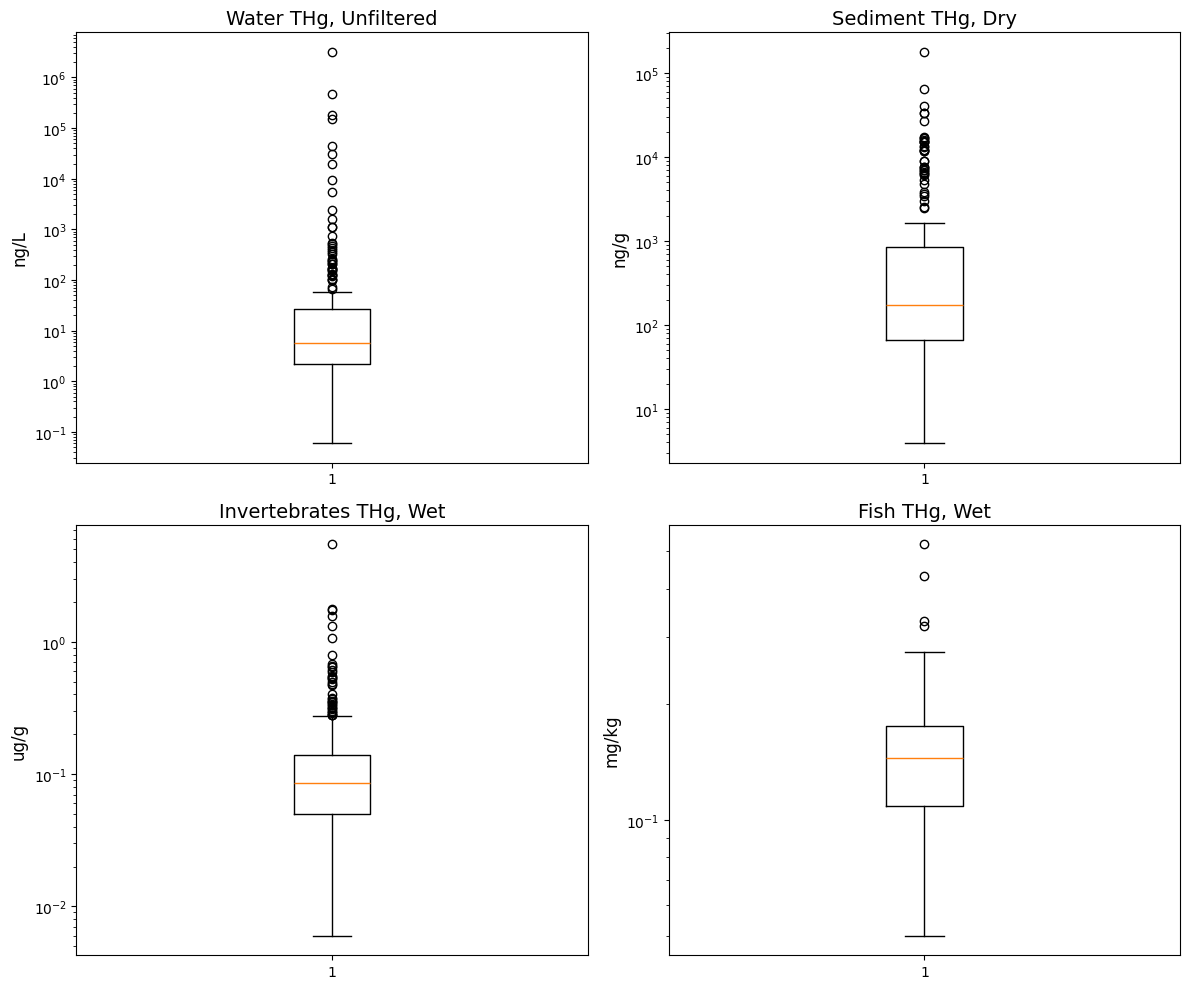

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].boxplot(water["thg_unfiltered_clean"].dropna())
axes[0, 0].set_title("Water THg, Unfiltered")
axes[0, 0].set_ylabel("ng/L")
axes[0, 0].set_yscale("log")

axes[0, 1].boxplot(sediment["thg_dry_clean"].dropna())
axes[0, 1].set_title("Sediment THg, Dry")
axes[0, 1].set_ylabel("ng/g")
axes[0, 1].set_yscale("log")

axes[1, 0].boxplot(invert["thg_wet_clean"].dropna())
axes[1, 0].set_title("Invertebrates THg, Wet")
axes[1, 0].set_ylabel("ug/g")
axes[1, 0].set_yscale("log")

axes[1, 1].boxplot(fish["thg_wet_clean"].dropna())
axes[1, 1].set_title("Fish THg, Wet")
axes[1, 1].set_ylabel("mg/kg")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3773/3744023928.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


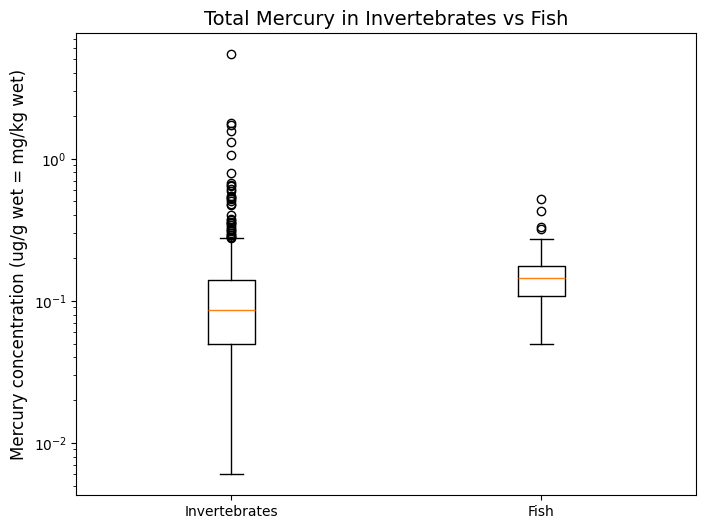

In [60]:
plt.figure(figsize=(8, 6))
plt.boxplot([
    invert["thg_wet_clean"].dropna(),
    fish["thg_wet_clean"].dropna()
], labels=["Invertebrates", "Fish"])

plt.yscale("log")
plt.ylabel("Mercury concentration (ug/g wet = mg/kg wet)")
plt.title("Total Mercury in Invertebrates vs Fish")
plt.show()

## Why Compare Water, Sediment, and Organisms?

Although these measurements come from different environmental media, comparing them is still useful.

This helps us visualize an important ecological pattern:

- Mercury may be relatively dilute in water
- Mercury can become concentrated in sediment
- Mercury can then bioaccumulate in organisms

This is not a perfect apples-to-apples comparison, because water is measured per volume and sediment/tissue are measured per mass.

However, the comparison is still valuable for understanding how mercury moves through the ecosystem and becomes concentrated over time.

/tmp/ipykernel_3773/2429332697.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


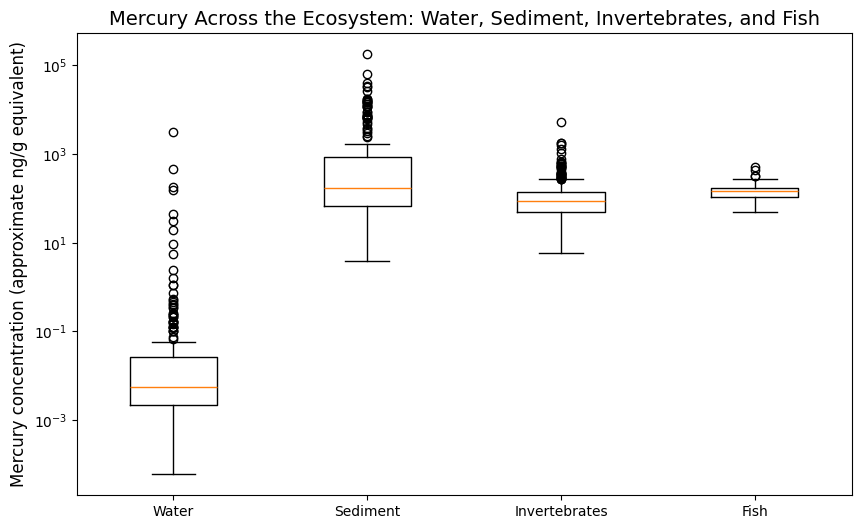

In [62]:
# Approximate water conversion:
# 1 L water ≈ 1000 g, so ng/L ≈ ng/1000 g = 0.001 ng/g

water["thg_ng_g_equiv"] = water["thg_unfiltered_clean"] / 1000

# Convert invertebrates and fish to ng/g for easier visual comparison
# 1 ug/g = 1000 ng/g
invert["thg_ng_g_equiv"] = invert["thg_wet_clean"] * 1000

# 1 mg/kg = 1 ug/g = 1000 ng/g
fish["thg_ng_g_equiv"] = fish["thg_wet_clean"] * 1000

# Sediment is already ng/g
sediment["thg_ng_g_equiv"] = sediment["thg_dry_clean"]

plt.figure(figsize=(10, 6))
plt.boxplot([
    water["thg_ng_g_equiv"].dropna(),
    sediment["thg_ng_g_equiv"].dropna(),
    invert["thg_ng_g_equiv"].dropna(),
    fish["thg_ng_g_equiv"].dropna()
], labels=["Water", "Sediment", "Invertebrates", "Fish"])

plt.yscale("log")
plt.ylabel("Mercury concentration (approximate ng/g equivalent)")
plt.title("Mercury Across the Ecosystem: Water, Sediment, Invertebrates, and Fish")
plt.show()

## Interpretation Questions

1. Which compartment shows the lowest mercury concentrations?
2. Which compartments show higher concentrations than water?
3. Does this support the idea that mercury becomes concentrated in sediment and organisms?
4. Why should we still be cautious about treating these values as perfectly equivalent?

## Step 5: Comparing Total Mercury (THg) and Methylmercury (MeHg)

So far, we have analyzed total mercury (THg), which represents all mercury present.

However, not all mercury behaves the same biologically.

👉 **Methylmercury (MeHg)** is the most important form because it:
- is readily absorbed by organisms
- accumulates in tissues
- increases up the food chain

Now we will compare THg and MeHg within organisms.

/tmp/ipykernel_3773/1764071576.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


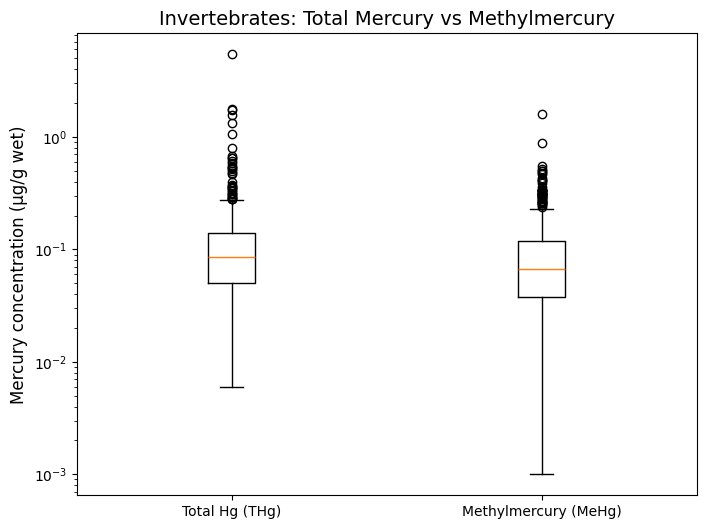

In [63]:
plt.figure(figsize=(8, 6))

plt.boxplot([
    invert["thg_wet_clean"].dropna(),
    invert["mehg_wet_clean"].dropna()
], labels=["Total Hg (THg)", "Methylmercury (MeHg)"])

plt.yscale("log")
plt.ylabel("Mercury concentration (µg/g wet)")
plt.title("Invertebrates: Total Mercury vs Methylmercury")

plt.show()

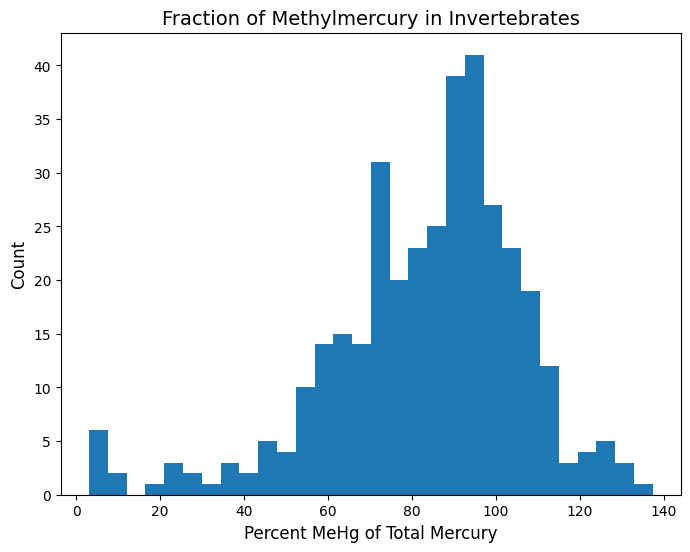

In [64]:
plt.figure(figsize=(8, 6))

plt.hist(invert["mehg_percent_clean"].dropna(), bins=30)

plt.xlabel("Percent MeHg of Total Mercury")
plt.ylabel("Count")
plt.title("Fraction of Methylmercury in Invertebrates")

plt.show()

### Interpretation Questions

1. Is methylmercury generally lower than total mercury?
2. What percentage of mercury is methylmercury in invertebrates?
3. Why might methylmercury be the dominant form in organisms?
4. How does this relate to toxicity in food webs?

### Key Insight

Even if total mercury is high, the **fraction that is methylmercury determines biological risk**.

👉 This is why environmental scientists focus heavily on MeHg.

In [61]:
print("Water columns:", water.columns.tolist())
print("Fish columns:", fish.columns.tolist())
print("Sites columns:", sites.columns.tolist())

Water columns: ['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Date', 'Time', 'Sample Type', 'Data References', 'Mercury, Unfiltered (ng/L)', 'Mercury, Unfiltered Data Source', 'Mercury, Filtered (ng/L)', 'Mercury, Filtered Data Source', 'Methylmercury, Unfiltered (ng/L)', 'Methylmercury, Unfiltered Data Source', 'Methylmercury, Filtered (ng/L)', 'Methylmercury, Filtered Data Source', 'thg_unfiltered_clean', 'thg_filtered_clean', 'mehg_unfiltered_clean', 'mehg_filtered_clean']
Fish columns: ['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Date', 'Sample Type', 'Common name ', 'Genus and Species', 'Sample Size', 'Body Part', 'Total Length (mm)', 'Total Length Standard Deviation', 'Total Weight (g) ', 'Total weight Standard Deviation', 'Total Mercury, Dry (mg/kg)', 'Total Mercury, Wet (mg/kg)', 'Moisture (percent)', 'Gender', 'thg_dry_clean', 'thg_wet_clean']
Sites columns: ['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Latitude', 'Longitud

## Step 6: Linking Mercury Across the Ecosystem

So far, we have looked at each dataset separately.

Now we ask a deeper question:

👉 Do sites with higher mercury in water also have higher mercury in organisms?

To answer this, we will connect datasets using shared site identifiers.

In [65]:
merged_wf = pd.merge(
    water,
    fish,
    on="Station Map ID",
    suffixes=("_water", "_fish")
)

print("Merged water + fish shape:", merged_wf.shape)
display(merged_wf.head())

Merged water + fish shape: (95, 39)


,Station Map ID,USGS Station Name_water,USGS Station Number_water,Date_water,Time,Sample Type_water,Data References,"Mercury, Unfiltered (ng/L)","Mercury, Unfiltered Data Source","Mercury, Filtered (ng/L)",...,Total Length Standard Deviation,Total Weight (g),Total weight Standard Deviation,"Total Mercury, Dry (mg/kg)","Total Mercury, Wet (mg/kg)",Moisture (percent),Gender,thg_dry_clean,thg_wet_clean,thg_ng_g_equiv_fish
0,BR-80,NF STEEPHOLLOW C NR BLUE CYN CA,391642120464701,7/1/1999,10:00,Environmental,NP,1.2,C2,1.2,...,ND,197.00,ND,0.885,0.191,78.4,Female,0.885,0.191,191.0
1,BR-80,NF STEEPHOLLOW C NR BLUE CYN CA,391642120464701,7/1/1999,10:00,Environmental,NP,1.2,C2,1.2,...,ND,105.00,ND,0.613,0.142,76.9,Male,0.613,0.142,142.0
2,LY-12,LARGE POND E OF BIG SEEP IN YUBA GOLDFIELDS,391304121235301,7/22/2003,11:40,Environmental,NP,1.8,W1,1.0,...,ND,57.80,ND,0.815,0.178,78.2,Male,0.815,0.178,178.0
3,LY-12,LARGE POND E OF BIG SEEP IN YUBA GOLDFIELDS,391304121235301,7/22/2003,11:40,Environmental,NP,1.8,W1,1.0,...,7.1,9.89,1.86,0.617,0.151,75.5,ND,0.617,0.151,151.0
4,LY-12,LARGE POND E OF BIG SEEP IN YUBA GOLDFIELDS,391304121235301,7/22/2003,11:40,Environmental,NP,1.8,W1,1.0,...,4.0,5.63,0.34,0.468,0.116,75.3,ND,0.468,0.116,116.0


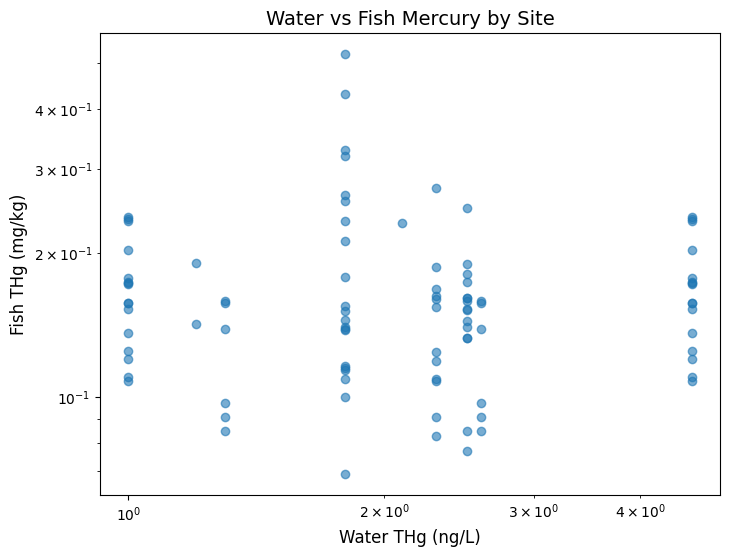

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(
    merged_wf["thg_unfiltered_clean"],
    merged_wf["thg_wet_clean"],
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Water THg (ng/L)")
plt.ylabel("Fish THg (mg/kg)")
plt.title("Water vs Fish Mercury by Site")

plt.show()

### Interpretation Questions

1. Do higher water mercury levels correspond to higher fish mercury levels?
2. Is the relationship strong or weak?
3. What factors might explain differences between sites?

👉 Consider:
- sediment interactions
- food web structure
- time lags in accumulation

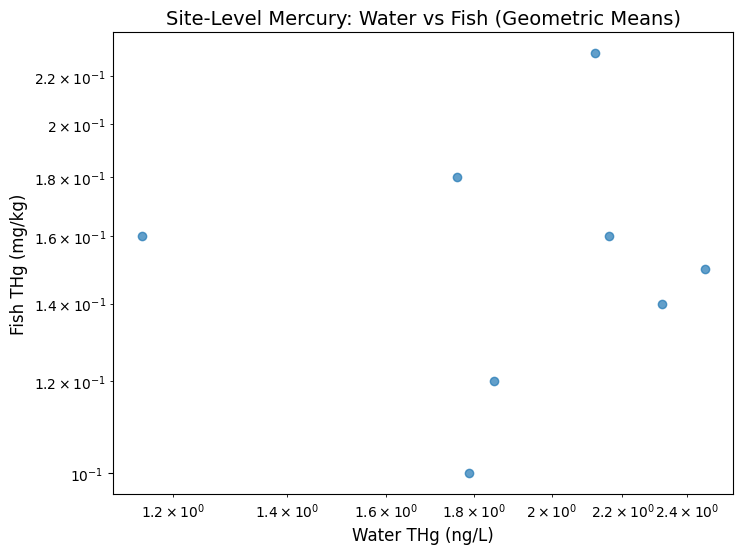